c:\Users\lpset\anaconda3\envs\arbitragelab_env\lib\site-packages\ot\backend.py:2998: UserWarning: To use TensorflowBackend, you need to activate the tensorflow numpy API. You can activate it by running: 
from tensorflow.python.ops.numpy_ops import np_config
np_config.enable_numpy_behavior()
  register_backend(TensorflowBackend())


Warning - Certain functionality 
             requires requests_html, which is not installed.
             
             Install using: 
             pip install requests_html
             
             After installation, you may have to restart your Python session.


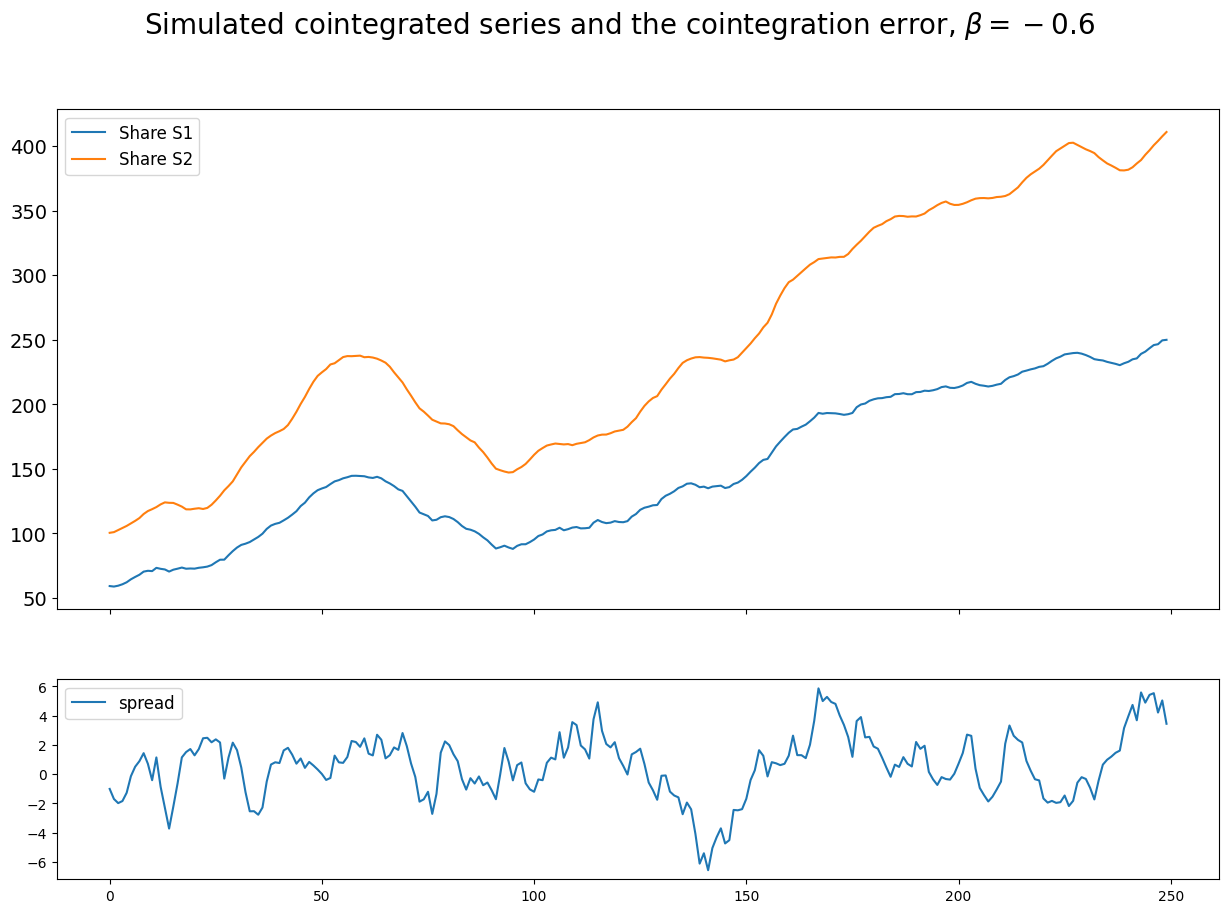

In [ ]:
# Importing packages
from arbitragelab.cointegration_approach.coint_sim import CointegrationSimulation

# Generate 50 cointegrated time series, each of which has 250 data points
coint_simulator = CointegrationSimulation(50, 250)

# Setup the parameters for the AR(1) processes and cointegration coefficient, beta
price_params = {
"ar_coeff": 0.95,
"white_noise_var": 1,
"constant_trend": 1.5}

coint_params = {
    "ar_coeff": 0.9,
    "white_noise_var": 1.,
    "constant_trend": 0.05,
    "beta": -0.6}

coint_simulator.load_params(price_params, target='price')
coint_simulator.load_params(coint_params, target='coint')

# Perform simulation
s1_series, s2_series, coint_errors = coint_simulator.simulate_coint(initial_price=100.,
                                                                    use_statsmodels=True)

# Verify if the simulated series are cointegrated and the cointegration coefficient is equal to beta
beta_mean, beta_std = coint_simulator.verify_coint(s1_series, s2_series)

# Plot an example of the simulated series and their corresponding cointegration error
coint_sim_fig = coint_simulator.plot_coint_series(s1_series[:, 0], s2_series[:, 0],
                                                  coint_errors[:, 0])


In [21]:
print(s1_series[:, 0])

[ 56.52997573  55.51653761  53.75553149  52.39160718  49.19169996
  46.84427837  43.37582017  40.41272105  38.15775426  36.53023089
  36.91399042  36.39983495  35.27689106  34.94524267  36.65068486
  35.913665    35.89126622  35.30230194  34.692407    33.29958928
  30.89639374  28.04669195  24.64765668  22.63765659  21.74546216
  19.02126156  18.15782703  16.2238894   13.6084696    8.709511
   5.51417068   2.56773784   0.18035526  -3.64161243  -6.09380482
  -8.05329007 -11.05374214 -13.74857211 -15.88294511 -17.87255987
 -19.64265831 -23.0368914  -23.56677047 -22.68726312 -23.9982344
 -25.07180339 -25.2044141  -24.88670739 -22.42645702 -22.07744166
 -20.90884558 -20.97336049 -22.62111457 -24.05134609 -24.6935252
 -24.67360277 -25.92930913 -27.54608892 -29.53110453 -31.10410391
 -31.82556397 -31.46653127 -31.08820865 -30.98085929 -31.62466733
 -33.16281602 -33.44438904 -31.58517201 -29.95174936 -29.83558133
 -28.10794269 -28.0883535  -27.18800854 -27.08649793 -24.49768754
 -23.94143011 